# Risk Investigation -- Expansion Layouts
Visual preview of random turbine layouts around the existing cluster, staying on the federal (OCS) side of the Submerged Lands Act boundary. No AEP or wake simulation here -- purely spatial.

Imports, dark theme, and shared paths.

In [1]:
import json

import numpy as np
import matplotlib.pyplot as plt
import windIO
from pyproj import Transformer
from shapely.geometry import Point, Polygon
from scipy.spatial import cKDTree

from config import SYSTEM_YAML, FIGURES_DIR
from cluster_layout import load_cluster, BOUNDARY_NAMES

plt.style.use("dark_background")
plt.rcParams["figure.facecolor"] = "#1e1e1e"
plt.rcParams["axes.facecolor"] = "#1e1e1e"
plt.rcParams["savefig.facecolor"] = "#1e1e1e"

SLA_PATH = "/Users/brunoboer/Desktop/Advanced_Optimizer/US_Cluster/Data/Federal_State_Boundary_SLA.geojson"
np.random.seed(0)


/opt/anaconda3/envs/Wind_2200/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Setup and Boundary Loading
Load the existing cluster (turbines + lease boundaries).

In [2]:
farms = load_cluster()
system_dat = windIO.load_yaml(SYSTEM_YAML)
boundary_polygons = system_dat["site"]["boundaries"]["polygons"]
boundary_by_name = dict(zip(BOUNDARY_NAMES, boundary_polygons))
cluster_shapes = [Polygon(zip(p["x"], p["y"])) for p in boundary_polygons]

cluster_x = np.concatenate([f["x"] for f in farms if f["n_turbines"] > 0])
cluster_y = np.concatenate([f["y"] for f in farms if f["n_turbines"] > 0])
print(f"Cluster: {len(cluster_x)} turbines across {len(farms)} farms")


Cluster: 1008 turbines across 12 farms


Load the SLA boundary, keep only the segments near our region, and reproject to UTM19N.

In [3]:
sla_raw = json.load(open(SLA_PATH))["features"][0]["geometry"]["coordinates"]

LON_MIN, LON_MAX = -72.5, -69.0
LAT_MIN, LAT_MAX = 40.5, 42.5
to_utm = Transformer.from_crs("EPSG:4326", "EPSG:32619", always_xy=True)

sla_lines_utm = []
for line in sla_raw:
    pts = np.array(line)
    mask = (pts[:, 0] >= LON_MIN) & (pts[:, 0] <= LON_MAX) & (pts[:, 1] >= LAT_MIN) & (pts[:, 1] <= LAT_MAX)
    if mask.sum() < 2:
        continue
    sub = pts[mask]
    x, y = to_utm.transform(sub[:, 0], sub[:, 1])
    sla_lines_utm.append(np.column_stack([x, y]))

print(f"SLA segments kept: {len(sla_lines_utm)}, total points: {sum(len(s) for s in sla_lines_utm)}")


SLA segments kept: 2, total points: 25779


Build a federal-vs-state side classifier: nearest SLA point plus local tangent, calibrated so the existing cluster is always on the federal side.

In [4]:
sla_all = np.vstack(sla_lines_utm)
tangents = np.zeros_like(sla_all)
offset = 0
for line in sla_lines_utm:
    n = len(line)
    tan = np.gradient(line, axis=0)
    tangents[offset:offset + n] = tan
    offset += n

sla_tree = cKDTree(sla_all)


def sla_side(xs, ys):
    pts = np.column_stack([xs, ys])
    _, idx = sla_tree.query(pts)
    vec = pts - sla_all[idx]
    cross = tangents[idx, 0] * vec[:, 1] - tangents[idx, 1] * vec[:, 0]
    return np.sign(cross)


FEDERAL_SIGN = np.sign(sla_side(cluster_x, cluster_y).mean())


def is_federal(xs, ys):
    return sla_side(xs, ys) == FEDERAL_SIGN


Plot 1: current cluster over the SLA boundary, showing the free federal area around it.

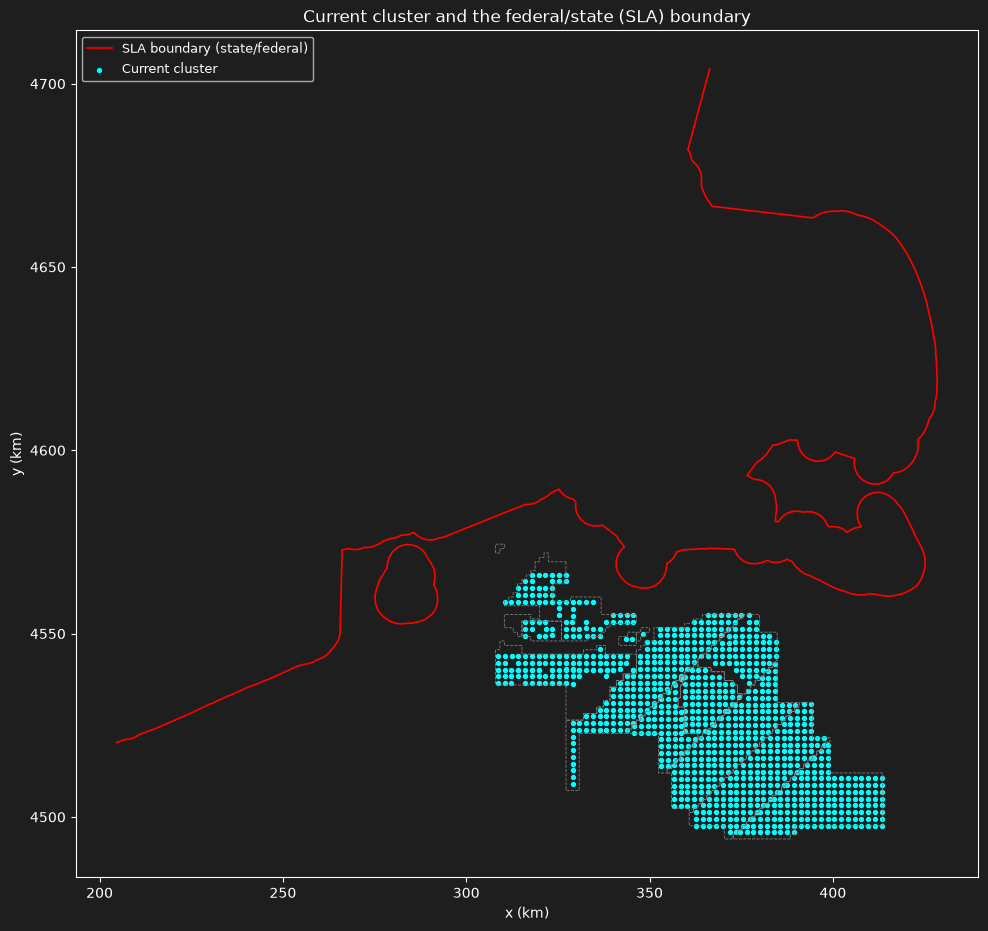

In [5]:
fig, ax = plt.subplots(figsize=(12, 11))
for line in sla_lines_utm:
    ax.plot(line[:, 0] / 1000, line[:, 1] / 1000, color="red", linewidth=1.2, label="_nolegend_")
ax.plot([], [], color="red", linewidth=1.2, label="SLA boundary (state/federal)")

ax.scatter(cluster_x / 1000, cluster_y / 1000, s=8, color="cyan", label="Current cluster")
for shape in cluster_shapes:
    bx, by = shape.exterior.xy
    ax.plot(np.array(bx) / 1000, np.array(by) / 1000, color="gray", linewidth=0.6, linestyle="--")

ax.set_xlabel("x (km)")
ax.set_ylabel("y (km)")
ax.set_aspect("equal")
ax.legend(fontsize=9, loc="upper left")
ax.set_title("Current cluster and the federal/state (SLA) boundary")
fig.savefig(FIGURES_DIR / "expansion_cluster_and_sla.png", dpi=180, bbox_inches="tight")
plt.show()


## 2. Random Scenario Sampling (Monte Carlo Preview)
Expansion search area: cluster bounding box plus a margin, used by every scenario below.

In [6]:
MARGIN_M = 40_000
BBOX = (cluster_x.min() - MARGIN_M, cluster_y.min() - MARGIN_M,
        cluster_x.max() + MARGIN_M, cluster_y.max() + MARGIN_M)


Grid generator: fills the search area at a fixed spacing, keeping only federal, non-overlapping points.

In [7]:
def fixed_grid(spacing):
    xmin, ymin, xmax, ymax = BBOX
    xs, ys = np.arange(xmin, xmax, spacing), np.arange(ymin, ymax, spacing)
    pts = [(x, y) for x in xs for y in ys
           if is_federal(np.array([x]), np.array([y]))[0]
           and not any(shape.contains(Point(x, y)) for shape in cluster_shapes)]
    return np.array(pts)


def sparse_grid():
    return fixed_grid(spacing=6000)


def dense_grid():
    return fixed_grid(spacing=2200)


grid_scenarios = {"Sparse grid": sparse_grid(), "Dense grid": dense_grid()}
for name, pts in grid_scenarios.items():
    print(f"{name}: {len(pts)} points")


Sparse grid: 554 points
Dense grid: 4004 points


## 3. Sequential Scenario Plots
Shared plotting helper: current cluster, SLA boundary, and one expansion scenario.

In [ ]:
def plot_scenario(name, pts, out_name):
    fig, ax = plt.subplots(figsize=(12, 11))
    for line in sla_lines_utm:
        ax.plot(line[:, 0] / 1000, line[:, 1] / 1000, color="red", linewidth=1.0)
    ax.scatter(cluster_x / 1000, cluster_y / 1000, s=8, color="cyan", label="Current cluster")
    if len(pts):
        ax.scatter(pts[:, 0] / 1000, pts[:, 1] / 1000, s=10, color="magenta", label=name)
    ax.set_xlabel("x (km)")
    ax.set_ylabel("y (km)")
    ax.set_aspect("equal")
    ax.legend(fontsize=9, loc="upper left")
    ax.set_title(f"Expansion preview -- {name} ({len(pts)} turbines)")
    # fig.savefig(FIGURES_DIR / out_name, dpi=180, bbox_inches="tight")
    plt.show()


Plot 2: sparse grid expansion scenario.

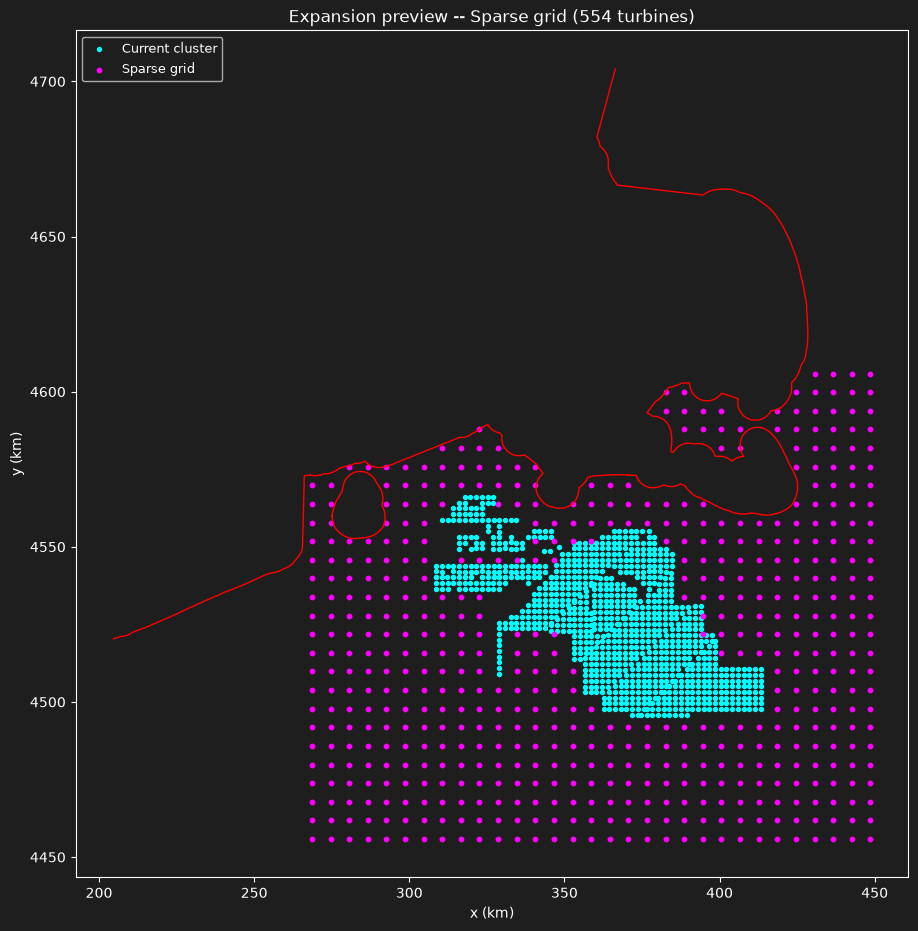

In [9]:
plot_scenario("Sparse grid", grid_scenarios["Sparse grid"], "expansion_sparse_grid.png")

Plot 3: dense grid expansion scenario.

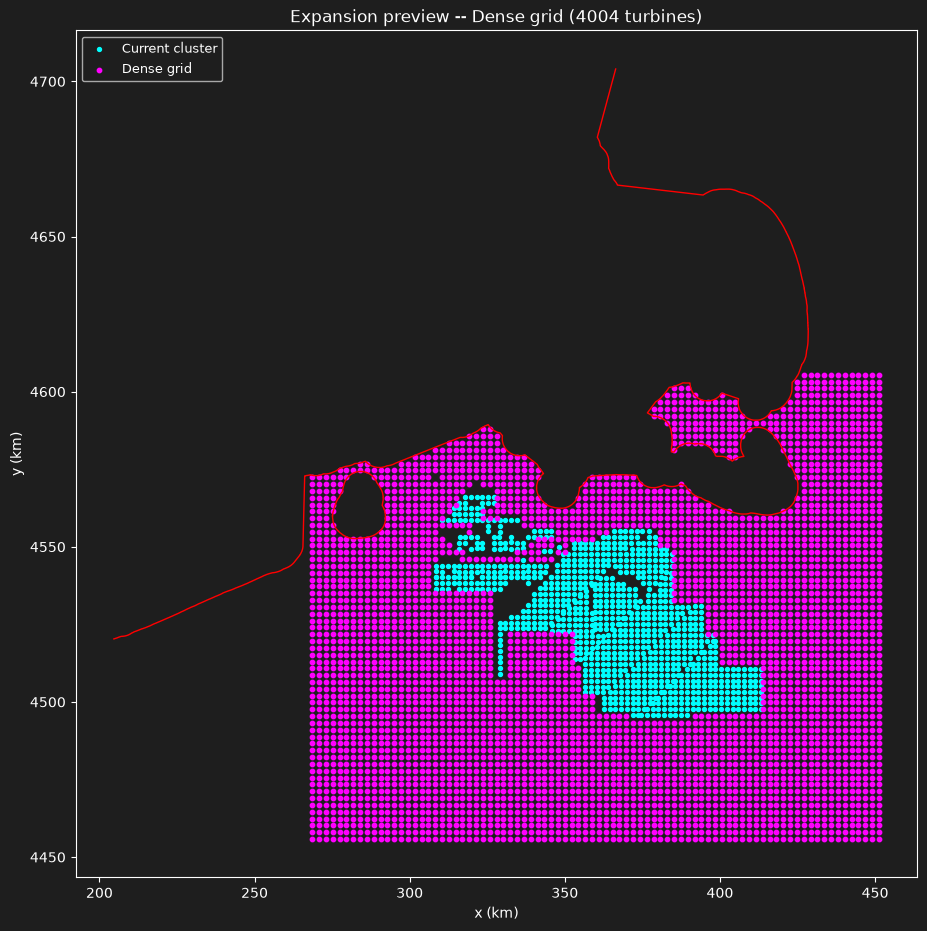

In [10]:
plot_scenario("Dense grid", grid_scenarios["Dense grid"], "expansion_dense_grid.png")

## 4. Mini-Farm Layouts (Future Monte Carlo Preview)
Instead of loose scattered turbines, sample whole new farms -- a bounded rectangle with its own internal turbine grid, sized small/medium/large -- placed randomly in the free federal area. This is closer to how the real Monte Carlo layout generator will draw future scenarios.

In [11]:
SPACING = 1800  # same reference spacing used for the synthetic cluster fill
FARM_SIZES = {"small": (4, 4), "medium": (7, 7), "large": (11, 11)}


def make_farm(center, rows, cols, angle_deg):
    angle = np.radians(angle_deg)
    rot = np.array([[np.cos(angle), -np.sin(angle)], [np.sin(angle), np.cos(angle)]])

    xs = (np.arange(cols) - (cols - 1) / 2) * SPACING
    ys = (np.arange(rows) - (rows - 1) / 2) * SPACING
    gx, gy = np.meshgrid(xs, ys)
    turbines = np.column_stack([gx.ravel(), gy.ravel()]) @ rot.T + center

    half_w, half_h = cols * SPACING / 2, rows * SPACING / 2
    corners = np.array([[-half_w, -half_h], [half_w, -half_h], [half_w, half_h], [-half_w, half_h]])
    boundary = Polygon(corners @ rot.T + center)
    return turbines[:, 0], turbines[:, 1], boundary


def farm_is_valid(boundary, placed_shapes):
    pts = np.array(boundary.exterior.coords)[:-1]
    pts = np.vstack([pts, [boundary.centroid.x, boundary.centroid.y]])
    if not is_federal(pts[:, 0], pts[:, 1]).all():
        return False
    return not any(boundary.intersects(shape) for shape in cluster_shapes + placed_shapes)


def generate_mini_farms(size_labels, seed, max_tries=500):
    rng = np.random.default_rng(seed)
    xmin, ymin, xmax, ymax = BBOX
    placed_shapes, farms_out = [], []
    for label in size_labels:
        rows, cols = FARM_SIZES[label]
        for _ in range(max_tries):
            center = rng.uniform([xmin, ymin], [xmax, ymax])
            angle = rng.uniform(0, 360)
            x, y, boundary = make_farm(center, rows, cols, angle)
            if farm_is_valid(boundary, placed_shapes):
                placed_shapes.append(boundary)
                farms_out.append(dict(label=label, x=x, y=y, boundary=boundary))
                break
    return farms_out


Plotting helper for a mini-farm scenario: each new farm gets its own color, boundary, and turbine grid.

In [12]:
def plot_mini_farms(ax, farms_list):
    for line in sla_lines_utm:
        ax.plot(line[:, 0] / 1000, line[:, 1] / 1000, color="red", linewidth=1.0)
    ax.scatter(cluster_x / 1000, cluster_y / 1000, s=8, color="cyan", label="Current cluster")

    colors = ["magenta", "yellow", "lime", "orange"]
    for i, farm in enumerate(farms_list):
        c = colors[i % len(colors)]
        bx, by = farm["boundary"].exterior.xy
        ax.plot(np.array(bx) / 1000, np.array(by) / 1000, color=c, linewidth=1.2)
        ax.scatter(farm["x"] / 1000, farm["y"] / 1000, s=10, color=c,
                   label=f"{farm['label'].title()} farm ({len(farm['x'])} turbines)")

    ax.set_xlabel("x (km)")
    ax.set_ylabel("y (km)")
    ax.set_aspect("equal")
    ax.legend(fontsize=8, loc="upper left")


Plot 4: one new large farm.

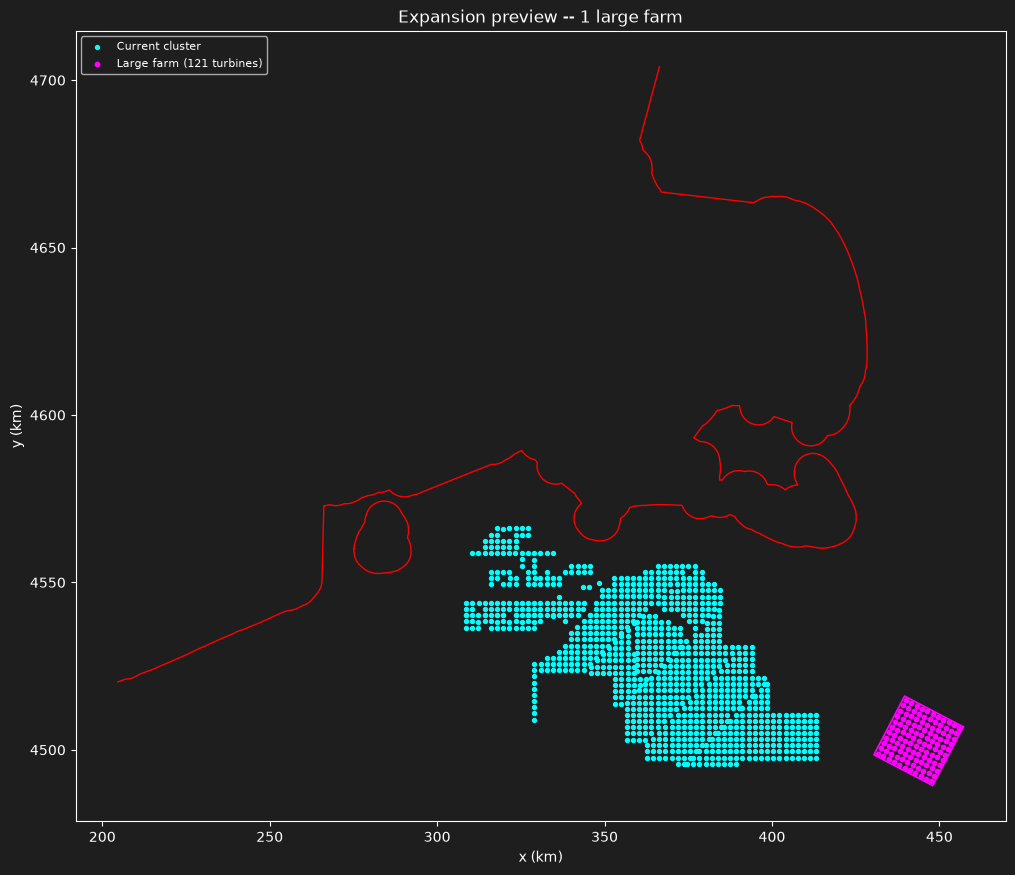

In [13]:
scenario_a = generate_mini_farms(["large"], seed=1)

fig, ax = plt.subplots(figsize=(12, 11))
plot_mini_farms(ax, scenario_a)
ax.set_title("Expansion preview -- 1 large farm")
fig.savefig(FIGURES_DIR / "expansion_mini_farms_1_large.png", dpi=180, bbox_inches="tight")
plt.show()


Plot 5: two new medium farms.

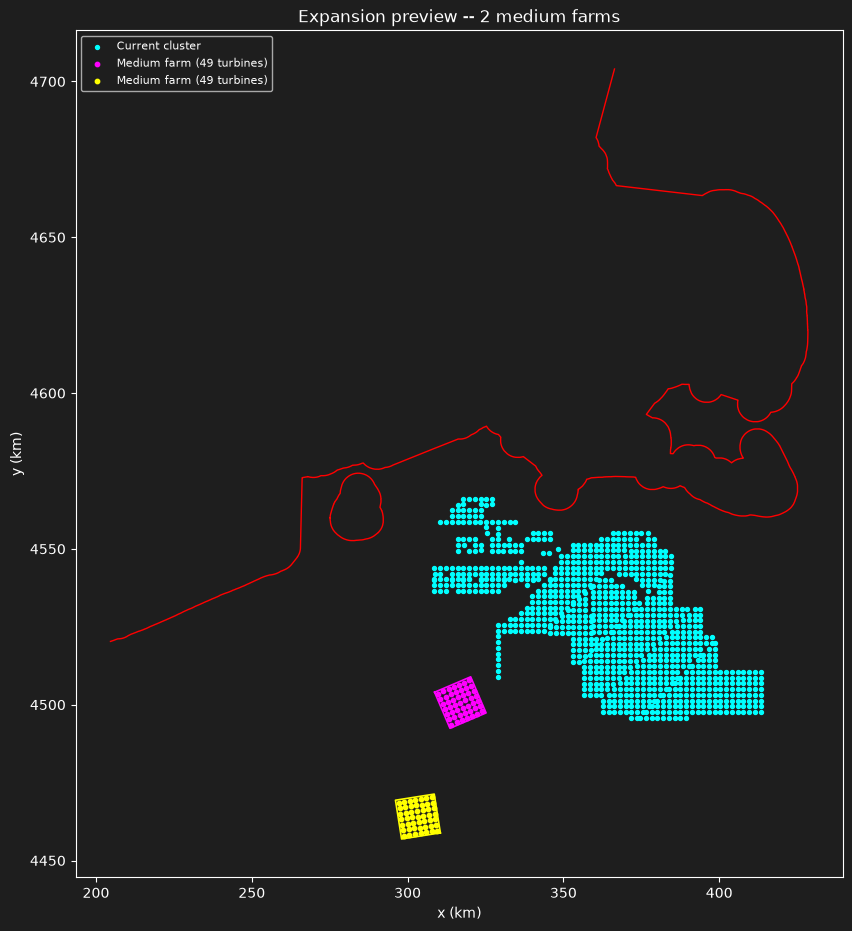

In [14]:
scenario_b = generate_mini_farms(["medium", "medium"], seed=2)

fig, ax = plt.subplots(figsize=(12, 11))
plot_mini_farms(ax, scenario_b)
ax.set_title("Expansion preview -- 2 medium farms")
fig.savefig(FIGURES_DIR / "expansion_mini_farms_2_medium.png", dpi=180, bbox_inches="tight")
plt.show()


Plot 6: three new farms, mixed sizes.

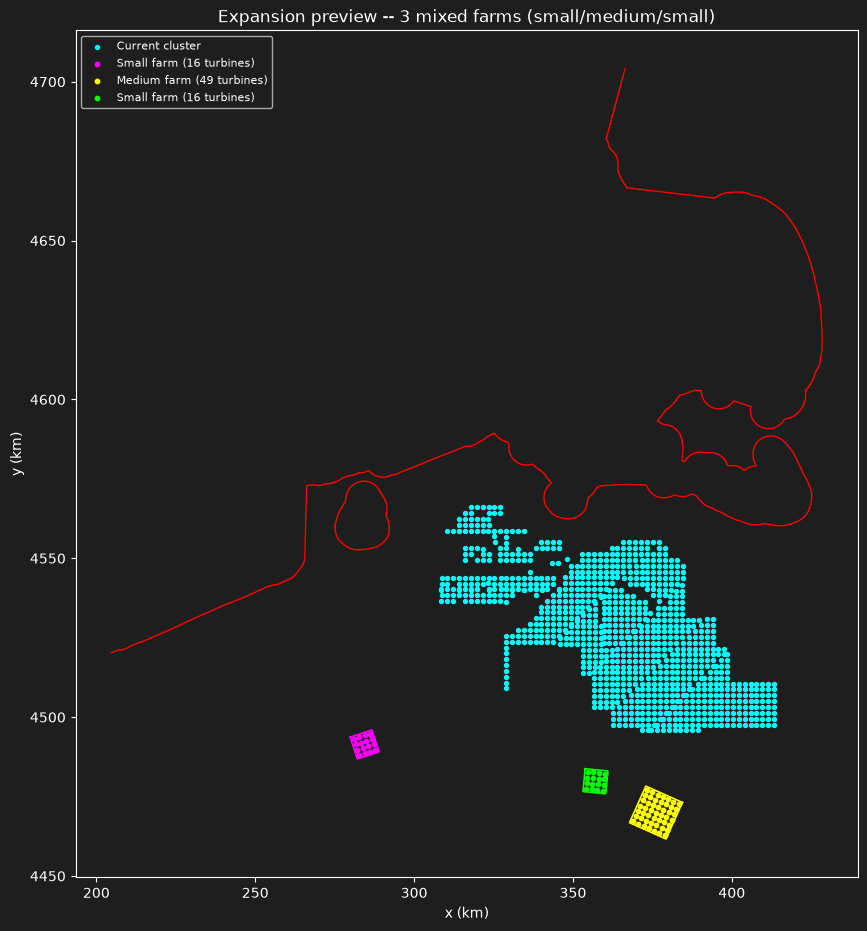

In [15]:
scenario_c = generate_mini_farms(["small", "medium", "small"], seed=3)

fig, ax = plt.subplots(figsize=(12, 11))
plot_mini_farms(ax, scenario_c)
ax.set_title("Expansion preview -- 3 mixed farms (small/medium/small)")
fig.savefig(FIGURES_DIR / "expansion_mini_farms_3_mixed.png", dpi=180, bbox_inches="tight")
plt.show()


## 5. Side-by-Side Comparison
Plot 7: every scenario in one grid, for direct comparison.

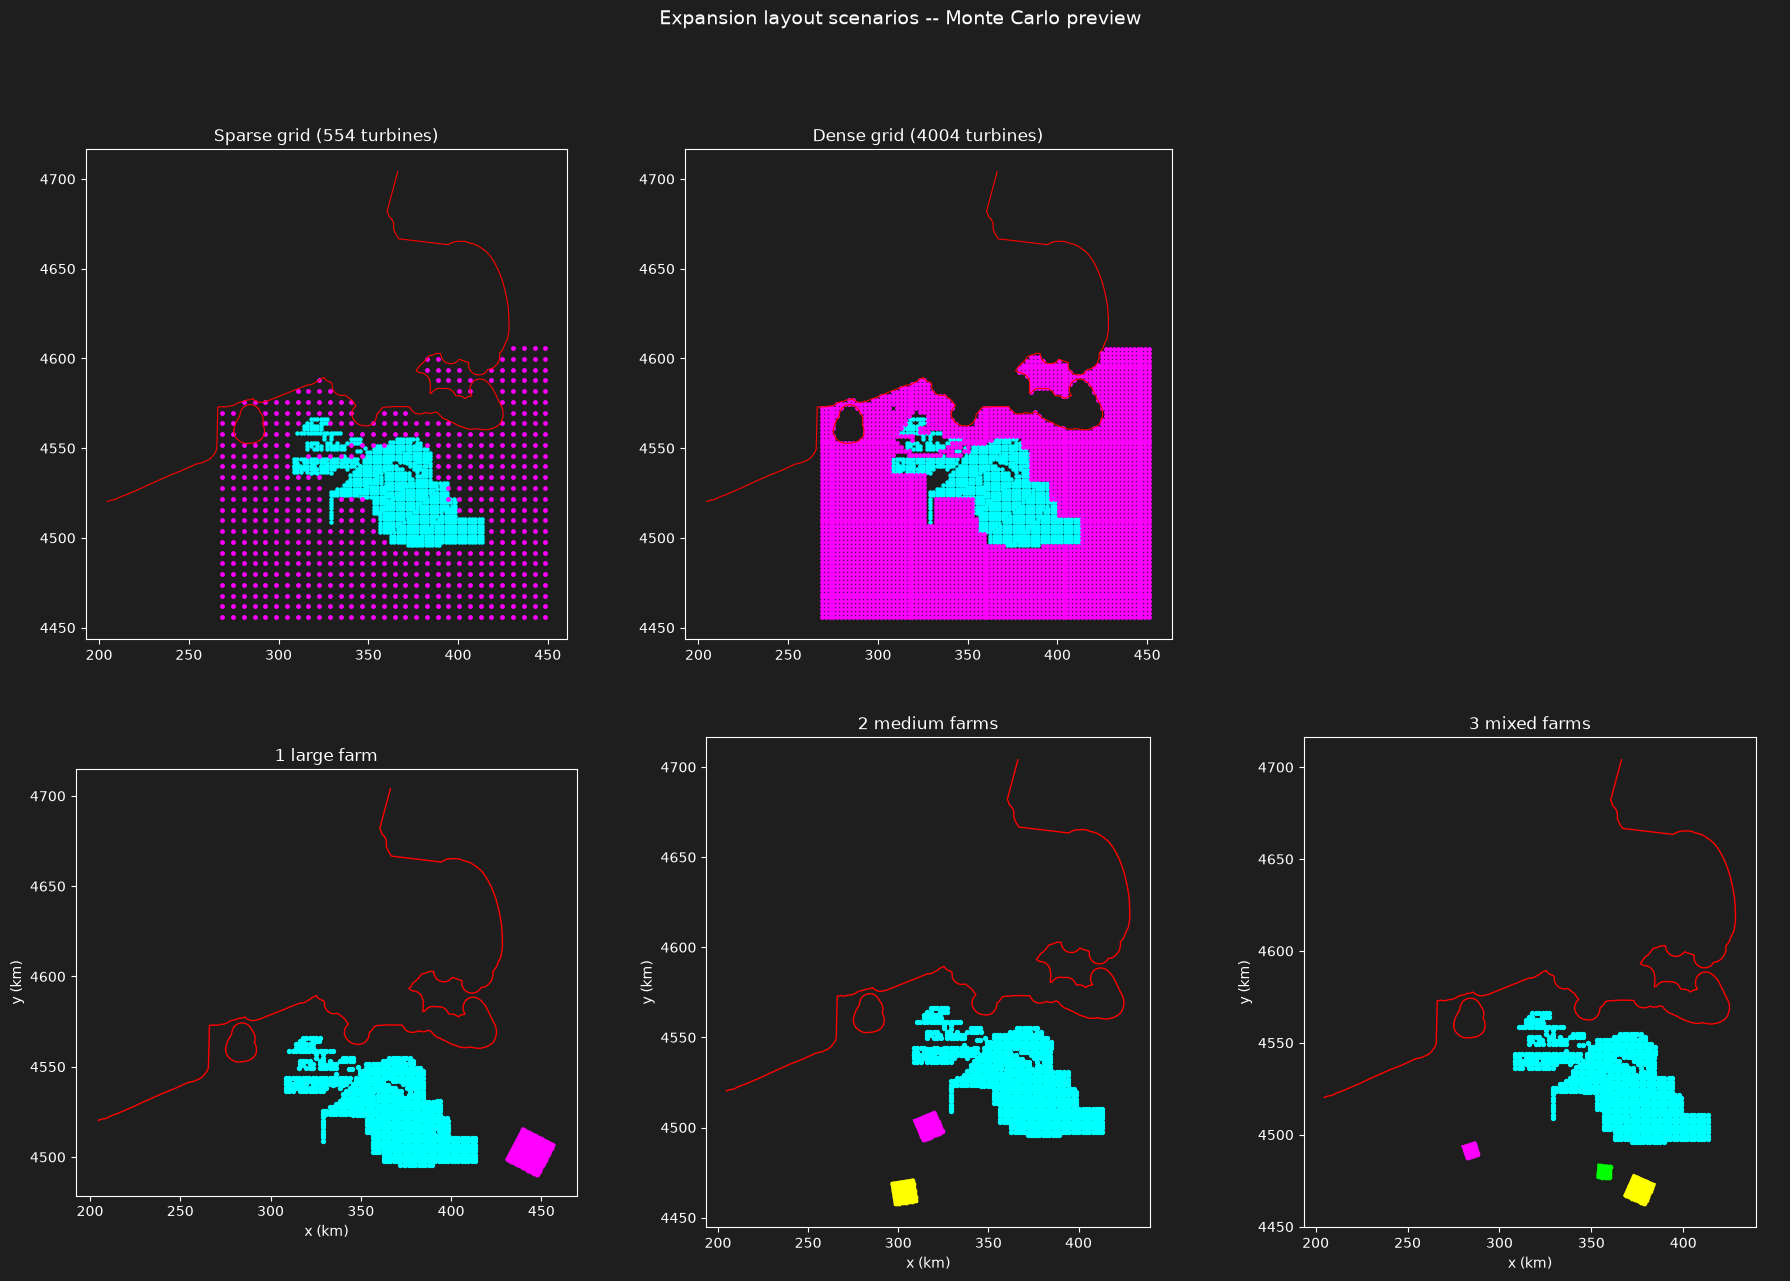

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(22, 14))

for ax, (name, pts) in zip(axes[0, :2], grid_scenarios.items()):
    for line in sla_lines_utm:
        ax.plot(line[:, 0] / 1000, line[:, 1] / 1000, color="red", linewidth=0.8)
    ax.scatter(cluster_x / 1000, cluster_y / 1000, s=5, color="cyan")
    ax.scatter(pts[:, 0] / 1000, pts[:, 1] / 1000, s=6, color="magenta")
    ax.set_aspect("equal")
    ax.set_title(f"{name} ({len(pts)} turbines)")
axes[0, 2].axis("off")

for ax, (name, farms_list) in zip(axes[1, :], [("1 large farm", scenario_a),
                                                ("2 medium farms", scenario_b),
                                                ("3 mixed farms", scenario_c)]):
    plot_mini_farms(ax, farms_list)
    ax.get_legend().remove()
    ax.set_title(name)

fig.suptitle("Expansion layout scenarios -- Monte Carlo preview", fontsize=14)
fig.savefig(FIGURES_DIR / "expansion_all_scenarios_grid.png", dpi=180, bbox_inches="tight")
plt.show()
